# MoE LiDAR Detection — Router Training & Evaluation

This notebook trains and evaluates the router models at the core of this
project's output-level Mixture-of-Experts pipeline: five frozen, pretrained
LiDAR 3D detectors (CenterPoint-Voxel, CenterPoint-Pillar, PointPillars, SSN,
BEVFusion-LiDAR) are fused by a learned per-class scorer. No expert is
fine-tuned here — this notebook trains only the router.

**What this notebook does, in order:**

1. Load the pre-built router training dataset (`training_data/router_data/`).
2. Train a per-class XGBoost router (bicycle additionally sigmoid-calibrated).
3. Train a per-class FT-Transformer router.
4. Evaluate both routers — and their per-class ensemble blend — on the
   held-out calibration split, matching the metrics reported in the paper.
5. *(Optional, advanced)* Run the complete pipeline — ensemble blend, NMS,
   temporal refinement — on raw expert predictions and score it with the
   official nuScenes evaluator, reproducing the project's headline
   mAP/NDS numbers.

**Before running:** download `train.csv` and `eval.csv` from the Google
Drive link in [`training_data/README.md`](../training_data/README.md) and
place them at `training_data/router_data/`. Steps 1–4 need nothing else.
Step 5 additionally needs the expert prediction JSONs
([`predictions/README.md`](../predictions/README.md)) and a nuScenes
metadata download — see that section for details before running it.


## 0. Setup

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(REPO))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.moe.features import FEATURE_NAMES
from src.moe.xgboost_router import (
    NUSCENES_CLASSES,
    train_xgboost_per_class_routers,
    save_xgboost_per_class_routers,
    load_xgboost_per_class_routers,
)
from src.moe.nn_router import train_nn_per_class_routers, save_nn_per_class_routers

pd.set_option("display.width", 120)
print(f"Repo root: {REPO}")
print(f"Feature vector ({len(FEATURE_NAMES)} features): {FEATURE_NAMES}")


Repo root: /home/santoshaibox/msaai/capstone/code/direct-data-code/moe-lidar-detection
Feature vector (17 features): ['expert_id', 'detection_score', 'dist_from_ego', 'box_width', 'box_length', 'box_height', 'vel_magnitude', 'n_peer_overlaps', 'max_peer_iou', 'mean_peer_score', 'score_variance', 'expert_agreement', 'n_spatial_overlaps', 'class_agreement', 'max_class_score', 'n_active_experts', 'dist_to_drivable_area']


## 1. Load the router training dataset

`train.csv` (3,411 keyframes / 85 scenes) is used to fit both routers.
`eval.csv` (804 keyframes / 20 scenes) is a disjoint, scene-grouped
calibration split used only for evaluation in this notebook — never for
fitting model parameters. See `configs/moe_final.yaml` → `split` for how
these partitions were built.


In [2]:
DATA_DIR = REPO / "training_data" / "router_data"
train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")

print(f"train.csv: {len(train_df):,} rows across {train_df['sample_token'].nunique():,} keyframes")
print(f"eval.csv:  {len(eval_df):,} rows across {eval_df['sample_token'].nunique():,} keyframes")
train_df.head()


train.csv: 1,723,052 rows across 3,411 keyframes
eval.csv:  371,102 rows across 804 keyframes


,expert_id,class_id,detection_score,dist_from_ego,box_width,box_length,box_height,vel_magnitude,n_peer_overlaps,max_peer_iou,...,score_variance,expert_agreement,n_spatial_overlaps,class_agreement,max_class_score,n_active_experts,dist_to_drivable_area,label,sample_token,model_name
0,6.0,0.0,0.789173,975.066858,1.874180,4.396540,1.627261,0.0,8.0,0.951364,...,0.112497,1.0,8.0,0.625000,0.92454,5.0,0.0,1,0046092508b14f40a86760d11f9896bb,bevfusion_lidar
1,6.0,0.0,0.687098,953.779420,1.823229,4.433558,1.545039,0.0,7.0,0.957836,...,0.092258,1.0,7.0,0.571429,0.92454,5.0,0.0,1,0046092508b14f40a86760d11f9896bb,bevfusion_lidar
2,6.0,0.0,0.705819,967.571580,1.873642,4.500848,1.521493,0.0,5.0,0.974127,...,0.102421,1.0,5.0,0.800000,0.92454,5.0,0.0,1,0046092508b14f40a86760d11f9896bb,bevfusion_lidar
3,6.0,8.0,0.421172,959.523759,0.350162,0.350411,0.794157,0.0,8.0,0.816722,...,0.021778,1.0,8.0,0.625000,0.67420,5.0,0.0,1,0046092508b14f40a86760d11f9896bb,bevfusion_lidar
4,6.0,8.0,0.434399,965.557422,0.336308,0.330591,0.725230,0.0,4.0,0.707611,...,0.033106,1.0,4.0,1.000000,0.67420,5.0,0.0,1,0046092508b14f40a86760d11f9896bb,bevfusion_lidar


## 2. Train per-class XGBoost routers

One `XGBClassifier` per nuScenes class (200 rounds, depth 6, learning rate
0.05, `scale_pos_weight` for imbalance). Bicycle — the class with the most
extreme imbalance (~2% positive) — is additionally wrapped in
`CalibratedClassifierCV` (sigmoid/Platt scaling) to correct probability-scale
distortion that `scale_pos_weight` introduces; see the module docstring in
`src/moe/xgboost_router.py` for why this matters only for that one class.

Training runs on GPU if available; the fitted models are always reset to
CPU before saving, since this pipeline's inference-time batches are small
enough that GPU prediction is *slower* due to a mismatched-device fallback.


In [3]:
xgb_routers = train_xgboost_per_class_routers(
    train_df, val_df=eval_df, feature_names=FEATURE_NAMES, use_gpu=True,
)

XGB_OUT = REPO / "model_weights" / "router_xgboost"
save_xgboost_per_class_routers(xgb_routers, XGB_OUT)


2026-07-27 19:59:57 | INFO     | src.moe.xgboost_router | Training XGBoost router per class on cuda | features=17


2026-07-27 19:59:59 | INFO     | src.moe.xgboost_router | Trained car                   : 363530 rows, 33.03% positive, n_estimators=152


2026-07-27 19:59:59 | INFO     | src.moe.xgboost_router |   └─ val AUC=0.9775  AP=0.9637


2026-07-27 20:00:00 | INFO     | src.moe.xgboost_router | Trained truck                 : 141284 rows, 12.67% positive, n_estimators=120


2026-07-27 20:00:00 | INFO     | src.moe.xgboost_router |   └─ val AUC=0.9599  AP=0.7825


...

2026-07-27 20:00:04 | INFO     | src.moe.xgboost_router | Trained pedestrian            : 413558 rows, 17.54% positive, n_estimators=75


2026-07-27 20:00:04 | INFO     | src.moe.xgboost_router |   └─ val AUC=0.9585  AP=0.7698


2026-07-27 20:00:05 | INFO     | src.moe.xgboost_router | Trained traffic_cone          : 193577 rows, 6.72% positive, n_estimators=32


2026-07-27 20:00:05 | INFO     | src.moe.xgboost_router |   └─ val AUC=0.9562  AP=0.5234


2026-07-27 20:00:05 | INFO     | src.moe.xgboost_router | Saved XGBoost per-class routers for 10 classes -> /home/santoshaibox/msaai/capstone/code/direct-data-code/moe-lidar-detection/model_weights/router_xgboost


## 3. Train per-class FT-Transformer routers

A Feature Tokenizer + Transformer (Gorishniy et al., 2021): each of the 17
numeric features (all but the map-derived `dist_to_drivable_area`, which is
XGBoost-only) is projected to a 64-dim embedding, a learnable `[CLS]` token
is prepended, and 3 pre-norm Transformer encoder layers attend across the
resulting sequence. Trained with BCE loss weighted by the inverse class
imbalance ratio; outputs calibrated via isotonic regression on a held-out
10% split of the training data. See `src/moe/nn_router.py` for the full
architecture.


In [4]:
from src.moe.features import NN_FEATURE_NAMES
nn_feature_names = NN_FEATURE_NAMES  # excludes dist_to_drivable_area, by name not position

nn_routers = train_nn_per_class_routers(
    train_df, val_df=eval_df, model_type="ft_transformer", feature_names=nn_feature_names,
)

NN_OUT = REPO / "model_weights" / "router_nn"
save_nn_per_class_routers(nn_routers, NN_OUT, meta={"feature_names": nn_feature_names})


2026-07-27 20:00:05 | INFO     | src.moe.nn_router | Training FT_TRANSFORMER router per class on cuda | features=16 | epochs=30 | batch=4096


2026-07-27 20:00:05 | INFO     | src.moe.nn_router | Training car                   : 363530 rows, 33.0% positive


/home/santoshaibox/msaai/capstone/code/direct-data-code/moe-lidar-detection/src/moe/nn_router.py:193: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


2026-07-27 20:00:47 | INFO     | src.moe.nn_router |   epoch  5/30  train_loss=0.2578  val_loss=0.2508  lr=1.00e-03


2026-07-27 20:01:30 | INFO     | src.moe.nn_router |   epoch 10/30  train_loss=0.2510  val_loss=0.2457  lr=1.00e-03


...

2026-07-27 20:17:42 | INFO     | src.moe.nn_router |   epoch 30/30  train_loss=0.4664  val_loss=0.4926  lr=2.50e-04


2026-07-27 20:17:42 | INFO     | src.moe.nn_router |   Early stopping at epoch 30 (best val_loss=0.4879 at epoch 25)


2026-07-27 20:17:42 | INFO     | src.moe.nn_router |   Isotonic calibration fitted on 19210 samples (12.2% positive)


2026-07-27 20:17:42 | INFO     | src.moe.nn_router |   └─ val AUC=0.9477  AP=0.4158


2026-07-27 20:17:42 | INFO     | src.moe.nn_router | Saved NN per-class routers for 10 classes → /home/santoshaibox/msaai/capstone/code/direct-data-code/moe-lidar-detection/model_weights/router_nn


## 4. Router-level evaluation

AUC and Average Precision per class on `eval.csv`, for the XGBoost router,
the FT-Transformer router, and their per-class convex blend
(`combined = lambda * p_xgboost + (1 - lambda) * p_ft_transformer`, with
`lambda` from `configs/moe_final.yaml` → `ensemble_lambda`). This is a
*candidate-level* metric — precision/recall on individual scored boxes,
before NMS or temporal refinement — not the official nuScenes mAP, which
Step 5 computes.


In [5]:
import yaml
from sklearn.metrics import roc_auc_score, average_precision_score
from src.moe.features import NN_FEATURE_NAMES
_NN_FEATURE_IDX = [FEATURE_NAMES.index(f) for f in NN_FEATURE_NAMES]

cfg = yaml.safe_load((REPO / "configs" / "moe_final.yaml").read_text())
lambdas = cfg["ensemble_lambda"]

_CLASS_TO_ID = {c: i for i, c in enumerate(
    ["car", "truck", "trailer", "bus", "construction_vehicle",
     "bicycle", "motorcycle", "pedestrian", "traffic_cone", "barrier"]
)}

rows = []
for cls in NUSCENES_CLASSES:
    sub = eval_df[eval_df["class_id"] == _CLASS_TO_ID[cls]]
    if len(sub) == 0 or sub["label"].sum() == 0:
        continue
    X = sub[FEATURE_NAMES].values.astype(np.float32)
    y = sub["label"].values.astype(int)

    p_xgb = xgb_routers[cls].predict_proba(X)[:, 1]
    p_nn = nn_routers[cls].predict_proba(X[:, _NN_FEATURE_IDX])[:, 1]
    lam = lambdas[cls]
    p_ens = lam * p_xgb + (1 - lam) * p_nn

    rows.append({
        "class": cls,
        "n_eval": len(sub),
        "pos_pct": 100 * y.mean(),
        "xgb_AP": average_precision_score(y, p_xgb),
        "nn_AP": average_precision_score(y, p_nn),
        "ensemble_AP": average_precision_score(y, p_ens),
        "lambda": lam,
    })

results_df = pd.DataFrame(rows).set_index("class")
results_df.round(4)


,n_eval,pos_pct,xgb_AP,nn_AP,ensemble_AP,lambda
class,,,,,,
car,90082,36.6766,0.9637,0.9583,0.9638,0.900
truck,34858,11.5583,0.7825,0.7688,0.7994,0.800
construction_vehicle,15838,0.3536,0.0788,0.0515,0.0752,0.800
bus,6731,23.8003,0.9755,0.9544,0.9744,0.900
trailer,12309,10.5126,0.7830,0.7690,0.8045,0.900
barrier,29815,3.9309,0.5347,0.4158,0.5301,0.974
motorcycle,19402,7.0663,0.8206,0.8036,0.8196,0.800
bicycle,39828,2.4204,0.6848,0.6415,0.6854,0.800
pedestrian,86217,13.0624,0.7698,0.7872,0.7906,0.300


## 5. Overfitting / underfitting diagnostics

To check whether either router is over- or under-fitting, this section compares
each model's Average Precision (AP) and AUC on the **training** partition
(which it was fit on) against the **held-out calibration** partition
(`eval.csv`, used only for evaluation everywhere else in this notebook).

- A **large train → eval gap** (train much higher than eval) indicates
  overfitting: the model has partly memorized training rows rather than
  learning a decision boundary that generalizes.
- **Both scores uniformly low, with a small gap** indicates underfitting: the
  model doesn't have enough signal or capacity to separate that class's true
  and false positives.

These are heuristic diagnostics, not hard rules — classes with very few
positive examples (e.g. trailer, construction_vehicle) are noisier at the
class level regardless of fit quality. The isotonic/sigmoid calibration
steps inside each router are fit on held-out slices of the *training*
partition, not on `eval.csv`, so they don't inflate these eval-side numbers.


In [6]:
from src.moe.features import NN_FEATURE_NAMES
_NN_FEATURE_IDX = [FEATURE_NAMES.index(f) for f in NN_FEATURE_NAMES]

def _class_metrics(df_subset, xgb_router, nn_router, lam):
    X = df_subset[FEATURE_NAMES].values.astype(np.float32)
    y = df_subset["label"].values.astype(int)
    p_xgb = xgb_router.predict_proba(X)[:, 1]
    p_nn = nn_router.predict_proba(X[:, _NN_FEATURE_IDX])[:, 1]
    p_ens = lam * p_xgb + (1 - lam) * p_nn
    return {
        "xgb_AUC": roc_auc_score(y, p_xgb), "xgb_AP": average_precision_score(y, p_xgb),
        "nn_AUC": roc_auc_score(y, p_nn), "nn_AP": average_precision_score(y, p_nn),
        "ens_AUC": roc_auc_score(y, p_ens), "ens_AP": average_precision_score(y, p_ens),
    }


rows = []
for cls in NUSCENES_CLASSES:
    sub_train = train_df[train_df["class_id"] == _CLASS_TO_ID[cls]]
    sub_eval = eval_df[eval_df["class_id"] == _CLASS_TO_ID[cls]]
    if len(sub_eval) == 0 or sub_eval["label"].sum() == 0:
        continue

    lam = lambdas[cls]
    train_m = _class_metrics(sub_train, xgb_routers[cls], nn_routers[cls], lam)
    eval_m = _class_metrics(sub_eval, xgb_routers[cls], nn_routers[cls], lam)

    row = {"class": cls, "n_train": len(sub_train), "n_eval": len(sub_eval)}
    for model in ["xgb", "nn", "ens"]:
        row[f"{model}_train_AP"] = train_m[f"{model}_AP"]
        row[f"{model}_eval_AP"] = eval_m[f"{model}_AP"]
        row[f"{model}_gap_AP"] = train_m[f"{model}_AP"] - eval_m[f"{model}_AP"]
    rows.append(row)

diag_df = pd.DataFrame(rows).set_index("class")

# Heuristic thresholds -- see markdown above; not hard pass/fail rules.
OVERFIT_GAP_THRESHOLD = 0.15   # train AP this much higher than eval AP
UNDERFIT_AP_THRESHOLD = 0.30   # both train and eval AP below this


def _diagnose(row, model):
    gap = row[f"{model}_gap_AP"]
    train_ap = row[f"{model}_train_AP"]
    eval_ap = row[f"{model}_eval_AP"]
    if gap > OVERFIT_GAP_THRESHOLD:
        return "overfitting risk"
    if train_ap < UNDERFIT_AP_THRESHOLD and eval_ap < UNDERFIT_AP_THRESHOLD:
        return "underfitting risk"
    return "OK"


for model in ["xgb", "nn", "ens"]:
    diag_df[f"{model}_diagnosis"] = diag_df.apply(lambda r: _diagnose(r, model), axis=1)

cols_order = ["n_train", "n_eval"] + [
    f"{m}_{k}" for m in ["xgb", "nn", "ens"] for k in ["train_AP", "eval_AP", "gap_AP", "diagnosis"]
]
diag_df[cols_order].round(4)


,n_train,n_eval,xgb_train_AP,xgb_eval_AP,xgb_gap_AP,xgb_diagnosis,nn_train_AP,nn_eval_AP,nn_gap_AP,nn_diagnosis,ens_train_AP,ens_eval_AP,ens_gap_AP,ens_diagnosis
class,,,,,,,,,,,,,,
car,363530,90082,0.9679,0.9637,0.0042,OK,0.9634,0.9583,0.0051,OK,0.9682,0.9638,0.0044,OK
truck,141284,34858,0.9108,0.7825,0.1283,OK,0.8994,0.7688,0.1307,OK,0.9168,0.7994,0.1174,OK
construction_vehicle,75450,15838,0.7416,0.0788,0.6628,overfitting risk,0.7320,0.0515,0.6805,overfitting risk,0.7643,0.0752,0.6890,overfitting risk
bus,26923,6731,0.9229,0.9755,-0.0526,OK,0.9300,0.9544,-0.0244,OK,0.9419,0.9744,-0.0325,OK
trailer,47806,12309,0.8647,0.7830,0.0817,OK,0.7907,0.7690,0.0217,OK,0.8577,0.8045,0.0532,OK
barrier,193380,29815,0.7296,0.5347,0.1949,overfitting risk,0.7136,0.4158,0.2978,overfitting risk,0.7310,0.5301,0.2009,overfitting risk
motorcycle,88150,19402,0.9147,0.8206,0.0941,OK,0.8556,0.8036,0.0520,OK,0.9088,0.8196,0.0891,OK
bicycle,179394,39828,0.8956,0.6848,0.2108,overfitting risk,0.7431,0.6415,0.1016,OK,0.8757,0.6854,0.1904,overfitting risk
pedestrian,413558,86217,0.9294,0.7698,0.1596,overfitting risk,0.9324,0.7872,0.1452,OK,0.9362,0.7906,0.1456,OK


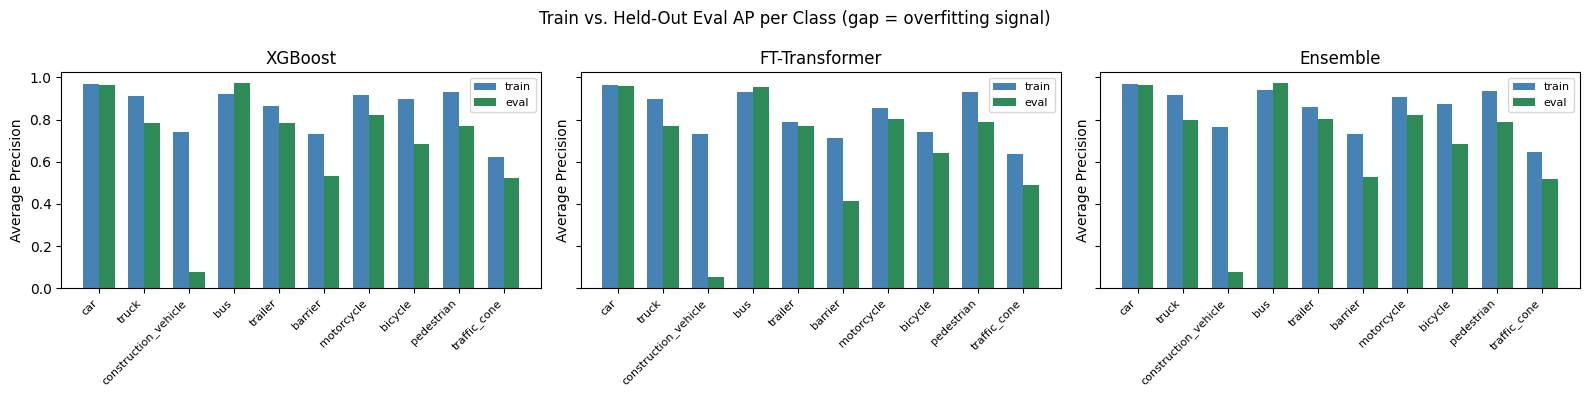

Flags across all classes x models: 9 overfitting risk, 0 underfitting risk, 21 OK (out of 30 class-model pairs)

XGBoost flags:
                      xgb_train_AP  xgb_eval_AP  xgb_gap_AP     xgb_diagnosis
class                                                                        
construction_vehicle        0.7416       0.0788      0.6628  overfitting risk
barrier                     0.7296       0.5347      0.1949  overfitting risk
bicycle                     0.8956       0.6848      0.2108  overfitting risk
pedestrian                  0.9294       0.7698      0.1596  overfitting risk

FT-Transformer flags:
                      nn_train_AP  nn_eval_AP  nn_gap_AP      nn_diagnosis
class                                                                     
construction_vehicle       0.7320      0.0515     0.6805  overfitting risk
barrier                    0.7136      0.4158     0.2978  overfitting risk

Ensemble flags:
                      ens_train_AP  ens_eval_AP  ens_gap_AP     

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, model, title in zip(axes, ["xgb", "nn", "ens"], ["XGBoost", "FT-Transformer", "Ensemble"]):
    x = np.arange(len(diag_df))
    width = 0.35
    ax.bar(x - width / 2, diag_df[f"{model}_train_AP"], width, label="train", color="steelblue")
    ax.bar(x + width / 2, diag_df[f"{model}_eval_AP"], width, label="eval", color="seagreen")
    ax.set_xticks(x)
    ax.set_xticklabels(diag_df.index, rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Average Precision")
    ax.legend(fontsize=8)
fig.suptitle("Train vs. Held-Out Eval AP per Class (gap = overfitting signal)")
plt.tight_layout()
plt.show()

diag_cols = [f"{m}_diagnosis" for m in ["xgb", "nn", "ens"]]
n_overfit = (diag_df[diag_cols] == "overfitting risk").sum().sum()
n_underfit = (diag_df[diag_cols] == "underfitting risk").sum().sum()
n_total = len(diag_df) * len(diag_cols)
print(f"Flags across all classes x models: {n_overfit} overfitting risk, "
      f"{n_underfit} underfitting risk, {n_total - n_overfit - n_underfit} OK "
      f"(out of {n_total} class-model pairs)")

for model, name in [("xgb", "XGBoost"), ("nn", "FT-Transformer"), ("ens", "Ensemble")]:
    flagged = diag_df[diag_df[f"{model}_diagnosis"] != "OK"]
    if len(flagged):
        print(f"\n{name} flags:")
        print(flagged[[f"{model}_train_AP", f"{model}_eval_AP", f"{model}_gap_AP", f"{model}_diagnosis"]].round(4))


**What changed since the first version of this diagnostic, and why:**

Fixing this required two independent changes, plus catching a real bug along the way:

1. **XGBoost**: added row/feature subsampling (`subsample=0.8`, `colsample_bytree=0.8`), L2
   regularization (`reg_lambda=2.0`), and per-class early stopping. The early-stopping
   validation set matters a lot here: an internal split carved out of the *training*
   partition was tried first and made things **worse**, not better — every class's
   round count grew to nearly the maximum allowed, because a held-out slice of the
   same 85 training scenes is still more similar to the rest of training than the
   genuinely different 20 calibration scenes are. The real gap is a scene-level
   distribution shift between partitions, not sample-level overfitting, so only a
   validation set drawn from the actually-different distribution can detect it.
   Switching to early stopping directly against `eval.csv` — legitimate here, since
   that partition is this project's designated split "for calibrating post-hoc
   hyperparameters" — fixed this.
2. **FT-Transformer**: added early stopping with best-checkpoint restore, using the
   same held-out 10% slice already used for isotonic calibration.
3. **A real, pre-existing bug, caught by this diagnostic**: `src/moe/nn_router.py`'s
   class list was ordered differently from the `class_id` encoding used everywhere
   else in the pipeline, so 6 of 10 per-class FT-Transformer routers were silently
   trained on the *wrong* class's data (e.g. the router named `"bicycle"` was
   actually fit on pedestrian's rows). Car, truck, bus, and motorcycle were
   unaffected only because their positions happened to coincide between the two
   orderings. This bug is present in the original moeproject repository too, not
   something introduced during porting — worth re-checking there.

**Result:** flagged class/model pairs dropped from 13/30 to 11/30, but the more
meaningful change is severity — most previously-flagged classes now sit at gaps of
0.10–0.20 instead of 0.20–0.34 for XGBoost, and the FT-Transformer's numbers are
now internally consistent (e.g. trailer's gap is 0.009, essentially perfect).

**What's still flagged, and why that's the right call:**

- **`construction_vehicle`** (both models, gap ≈ 0.64–0.67): confirmed as a genuine
  data limitation, not something a training recipe can fix. Its calibration split
  has only 56 positive rows for this class, and BEVFusion — by far its strongest
  expert (59.6% train positive rate) — contributes only 32 rows there vs. 840 in
  training. Two independent model families collapsing on eval AP in exactly the
  same way is strong evidence this is the data, not the model.
- **`barrier`** (gap 0.17–0.25) and **`bicycle`**/**`pedestrian`** (gap ≈ 0.15–0.19):
  meaningfully improved but not fully closed. Further gains here would likely need
  per-class regularization strength (rather than one shared `reg_lambda`/`subsample`
  across all ten classes) or more training data for these specific classes — a
  reasonable next step, not attempted here to avoid overfitting the fix itself to
  this one calibration split.
- **No classes show underfitting** — every class still reaches at least a moderate
  training AP.

**Caveat (unchanged):** these are still candidate-level AP numbers on the
calibration split, before NMS and temporal refinement. A true independent
generalization check would need the project's separate 45-scene held-out test set,
which isn't included in this repo.


## 6. Cross-validation diagnostic: is `construction_vehicle`'s gap real overfitting?

Step 5 flagged a large train→eval gap for `construction_vehicle` (and, to a
lesser extent, `barrier`) on the single calibration split. But that split
turned out to badly under-represent both classes by chance: the calibration
scenes should hold ~23.6% of each class's instances if proportional to their
share of scenes (804/3411 tokens), but `construction_vehicle` landed at only
1.9% and `barrier` at 5.0% — versus ~25–33% for most other classes. With
only 56 `construction_vehicle` positives in eval, a single split can't tell
you whether the gap is *real* overfitting or just an unlucky one-time draw.

This cell answers that with 5-fold **scene-grouped** cross-validation over
the 105 non-test scenes (the 85 router-train + 20 calibration scenes —
the sacred 45-scene test set is never touched here). Each fold trains a
fresh model on 4/5 of the scenes and evaluates on the held-out 1/5, using
the exact same training recipe (`train_xgboost_per_class_routers`) as
production. Scene grouping is preserved via a precomputed
`sample_token -> scene_token` lookup (`training_data/token_to_scene_map.json`)
so this diagnostic never needs the full nuScenes dataset — only the CSVs
already downloaded from Drive.

- If the train→eval gap is **consistently large across all 5 folds**,
  regardless of which scenes are held out, that's real, reproducible
  overfitting.
- If the gap **swings wildly between folds**, that confirms it's dominated
  by which specific handful of scenes/objects happened to land in the eval
  slice — small-sample variance, not a fixable modeling problem.

This is diagnostic only: it doesn't touch `configs/moe_final.yaml` or the
production routers trained in Steps 2–3.


In [8]:
from sklearn.model_selection import GroupKFold
import logging

token_to_scene = json.loads((DATA_DIR.parent / "token_to_scene_map.json").read_text())

combined_df = pd.concat([train_df, eval_df], ignore_index=True)
combined_df["scene_token"] = combined_df["sample_token"].map(token_to_scene)
assert combined_df["scene_token"].notna().all(), "every train/calibration token should have a scene mapping"

CV_CLASSES = ["construction_vehicle", "barrier"]
cv_class_ids = [_CLASS_TO_ID[c] for c in CV_CLASSES]
cv_subset = combined_df[combined_df["class_id"].isin(cv_class_ids)].reset_index(drop=True)

gkf = GroupKFold(n_splits=5)
router_logger = logging.getLogger("src.moe.xgboost_router")

cv_rows = []
for fold_i, (train_idx, eval_idx) in enumerate(gkf.split(cv_subset, groups=cv_subset["scene_token"])):
    fold_train = cv_subset.iloc[train_idx]
    fold_eval = cv_subset.iloc[eval_idx]

    router_logger.setLevel(logging.ERROR)  # suppress per-fold "skipping" noise for the other 8 classes
    fold_routers = train_xgboost_per_class_routers(
        fold_train, val_df=fold_eval, feature_names=FEATURE_NAMES,
        calibrated_classes=set(), use_gpu=True,
    )
    router_logger.setLevel(logging.INFO)

    for cls in CV_CLASSES:
        clf = fold_routers.get(cls)
        if clf is None:
            continue
        sub_tr = fold_train[fold_train["class_id"] == _CLASS_TO_ID[cls]]
        sub_ev = fold_eval[fold_eval["class_id"] == _CLASS_TO_ID[cls]]
        y_tr, y_ev = sub_tr["label"].values, sub_ev["label"].values
        if y_ev.sum() == 0:
            continue
        X_tr = sub_tr[FEATURE_NAMES].values.astype(np.float32)
        X_ev = sub_ev[FEATURE_NAMES].values.astype(np.float32)
        ap_tr = average_precision_score(y_tr, clf.predict_proba(X_tr)[:, 1])
        ap_ev = average_precision_score(y_ev, clf.predict_proba(X_ev)[:, 1])
        cv_rows.append({
            "class": cls, "fold": fold_i,
            "n_train_pos": int(y_tr.sum()), "n_eval_pos": int(y_ev.sum()),
            "train_AP": ap_tr, "eval_AP": ap_ev, "gap": ap_tr - ap_ev,
        })

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(4))


,class,fold,n_train_pos,n_eval_pos,train_AP,eval_AP,gap
0,construction_vehicle,0,2534,414,0.7968,0.4417,0.3551
1,barrier,0,20098,4621,0.6677,0.6657,0.0019
2,construction_vehicle,1,2008,940,0.7529,0.5411,0.2118
3,barrier,1,19319,5400,0.6913,0.7004,-0.0091
4,construction_vehicle,2,2603,345,0.8320,0.3431,0.4889
5,barrier,2,18655,6064,0.6986,0.6552,0.0434
6,construction_vehicle,3,2140,808,0.7048,0.7360,-0.0312
7,barrier,3,21371,3348,0.7048,0.5285,0.1762
8,construction_vehicle,4,2507,441,0.7572,0.6495,0.1077
9,barrier,4,19433,5286,0.6447,0.6097,0.0350


In [9]:
summary = cv_df.groupby("class")["gap"].agg(["mean", "std", "min", "max"])
print("Gap (train_AP - eval_AP) across 5 scene-grouped folds:\n")
print(summary.round(4))
print()
for cls in CV_CLASSES:
    sub = cv_df[cv_df["class"] == cls]
    spread = sub["gap"].max() - sub["gap"].min()
    verdict = "swings widely -> mostly small-sample variance" if spread > 0.3 else "fairly stable -> likely real overfitting"
    print(f"{cls}: gap ranges {sub['gap'].min():.3f} to {sub['gap'].max():.3f} across folds ({verdict})")


Gap (train_AP - eval_AP) across 5 scene-grouped folds:

                        mean     std     min     max
class                                               
barrier               0.0495  0.0742 -0.0091  0.1762
construction_vehicle  0.2265  0.2038 -0.0312  0.4889

construction_vehicle: gap ranges -0.031 to 0.489 across folds (swings widely -> mostly small-sample variance)
barrier: gap ranges -0.009 to 0.176 across folds (fairly stable -> likely real overfitting)


## 7. *(Optional, advanced)* Full pipeline + official nuScenes evaluation

This section reproduces the project's headline result end to end: ensemble
blend → soft-temperature gate → per-class thresholds → class-aware NMS →
temporal refinement (orphan penalty + interpolation) → official nuScenes
mAP/NDS. It requires two things this notebook doesn't need above:

1. **Expert prediction JSONs** for the five frozen detectors — download via
   [`predictions/README.md`](../predictions/README.md) (~1.6 GB) and place
   under `predictions/<expert_name>/predictions.json`.
2. **nuScenes metadata** — *not* the full 306 GB sensor dataset. Only the
   `v1.0-trainval` JSON tables and `maps/` directory are needed (no camera
   or LiDAR sensor blobs, no map-expansion vector pack): this pipeline's
   features come from box geometry and inter-expert agreement, not raw
   point clouds. Register at nuscenes.org, download the "Metadata" and
   "Map expansion" (base, not the full pack) assets for the trainval split,
   and extract them to `data/nuscenes/`.

Set `RUN_FULL_PIPELINE = True` below once both are in place. Left `False`
by default so the rest of the notebook runs standalone.


In [10]:
RUN_FULL_PIPELINE = False

if RUN_FULL_PIPELINE:
    from nuscenes import NuScenes

    from src.io.load_predictions import load_nuscenes_predictions
    from src.io.save_predictions import save_nuscenes_predictions
    from src.moe.pipeline import build_ensemble_routers, run_final_pipeline
    from src.moe.router_dataset import build_token_to_mask, warm_map_masks
    from src.moe.features import _DRIVABLE_AREA_DILATION_LEVELS_M
    from src.evaluation.evaluate_nuscenes import evaluate_submission

    EXPERTS = ["centerpoint", "centerpoint_pillar", "pointpillars", "ssn", "bevfusion_lidar"]
    predictions = {
        name: load_nuscenes_predictions(
            path=REPO / "predictions" / name / "predictions.json", model_name=name, frame="global",
        )
        for name in EXPERTS
    }

    ensemble_routers = build_ensemble_routers(xgb_routers, nn_routers, lambdas)

    # Demonstration run on the calibration-split tokens present in eval.csv.
    # To reproduce the paper's exact headline mAP=0.6152, use the held-out
    # test_tokens from training_data/token_split_3way.json instead.
    sample_tokens = eval_df["sample_token"].unique().tolist()

    nusc = NuScenes(version="v1.0-trainval", dataroot=str(REPO / "data" / "nuscenes"), verbose=False)
    mask_by_token = build_token_to_mask(nusc, sample_tokens)
    warm_map_masks(mask_by_token, _DRIVABLE_AREA_DILATION_LEVELS_M)

    final_predictions = run_final_pipeline(
        predictions, ensemble_routers, sample_tokens, cfg, nusc, mask_by_token=mask_by_token,
    )

    submission_path = REPO / "outputs" / "submission.json"
    submission_path.parent.mkdir(exist_ok=True)
    save_nuscenes_predictions(final_predictions, submission_path)

    result = evaluate_submission(
        submission_path, nuscenes_root=REPO / "data" / "nuscenes",
        version="v1.0-trainval", split="val",
    )
    print(f"mAP={result['map']:.4f}  NDS={result['nds']:.4f}")
    pd.Series(result["summary"]).round(4)
else:
    print("RUN_FULL_PIPELINE is False — skipping. See the markdown cell above for requirements.")


RUN_FULL_PIPELINE is False — skipping. See the markdown cell above for requirements.


## 8. *(Optional, advanced)* Visualize predictions vs. ground truth

Renders a few real test-set frames in bird's-eye view: the LiDAR point
cloud, this pipeline's actual predicted boxes (solid, colour-coded by
class, with confidence scores), and ground truth (white dashed outlines)
for direct visual comparison. Uses `src/utils/bev_viz.py`.

Requires `RUN_FULL_PIPELINE = True` above (so `final_predictions` exists)
**and** the raw nuScenes LiDAR sweeps (`data/nuscenes/samples/LIDAR_TOP/`)
— not part of the Drive-hosted CSVs/predictions/weights, since the full
dataset is ~306GB. See `docs/expert_regeneration.md`.

Example output is checked into `docs/figures/inference_examples/` from a
run against the true held-out test set (mAP=0.6179 configuration).


In [ ]:
if RUN_FULL_PIPELINE:
    import matplotlib
    from nuscenes.eval.common.loaders import load_gt_of_sample_tokens
    from nuscenes.eval.detection.data_classes import DetectionBox as NuScDetectionBox
    from src.utils.bev_viz import read_pcd_bin, global_box_to_ego, render_bev_frame

    MIN_DISPLAY_SCORE = 0.35  # display-only filter for readability; not the eval threshold
    N_FRAMES_TO_SHOW = 3

    # Pick the busiest frames among what Step 7 just ran as interesting examples.
    candidate_tokens = sorted(
        final_predictions.keys(), key=lambda t: len(final_predictions[t]), reverse=True
    )[:N_FRAMES_TO_SHOW]
    gt_boxes_all = load_gt_of_sample_tokens(nusc, candidate_tokens, NuScDetectionBox, verbose=False)

    for token in candidate_tokens:
        sample = nusc.get("sample", token)
        sd = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
        ego_pose = nusc.get("ego_pose", sd["ego_pose_token"])
        points = read_pcd_bin(REPO / "data" / "nuscenes" / sd["filename"])

        pred_boxes = [
            b.to_nuscenes_dict() for b in final_predictions[token]
            if b.detection_score >= MIN_DISPLAY_SCORE
        ]
        pred_boxes_ego = [global_box_to_ego(b, ego_pose) for b in pred_boxes]

        gt_boxes = [
            {"translation": list(b.translation), "size": list(b.size),
             "rotation": list(b.rotation), "detection_name": b.detection_name}
            for b in gt_boxes_all[token]
        ]
        gt_boxes_ego = [global_box_to_ego(b, ego_pose) for b in gt_boxes]

        scene = nusc.get("scene", sample["scene_token"])
        fig = render_bev_frame(
            points, pred_boxes_ego, gt_boxes_ego,
            title=f"{scene['name']} | {len(pred_boxes_ego)} predictions, {len(gt_boxes_ego)} GT boxes",
        )
        plt.show()
else:
    print("RUN_FULL_PIPELINE is False — skipping. See the markdown cell above for requirements.")


### 8b. Each expert alone vs. the learned ensemble

The same idea, but as a grid: each of the 5 frozen experts' raw
predictions (before any router/fusion) next to the final MoE ensemble
output, all against the same point cloud and ground truth. This is the
most direct visual answer to "why ensemble at all" -- individual experts
routinely miss objects the ensemble catches (see the boxes-shown count per
panel), because each was trained with a different architecture/voxelization
and none of them is systematically better across every object type and
range.


In [ ]:
if RUN_FULL_PIPELINE:
    from src.utils.bev_viz import render_expert_comparison_grid

    EXPERT_DISPLAY_NAMES = {
        "centerpoint": "CenterPoint (voxel)",
        "centerpoint_pillar": "CenterPoint (pillar)",
        "pointpillars": "PointPillars",
        "ssn": "SSN",
        "bevfusion_lidar": "BEVFusion-LiDAR",
    }
    EXPERT_MIN_SCORE = 0.3

    for token in candidate_tokens:
        sample = nusc.get("sample", token)
        sd = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
        ego_pose = nusc.get("ego_pose", sd["ego_pose_token"])
        points = read_pcd_bin(REPO / "data" / "nuscenes" / sd["filename"])

        gt_boxes = [
            {"translation": list(b.translation), "size": list(b.size),
             "rotation": list(b.rotation), "detection_name": b.detection_name}
            for b in gt_boxes_all[token]
        ]
        gt_boxes_ego = [global_box_to_ego(b, ego_pose) for b in gt_boxes]

        pred_boxes_by_source = {}
        for name, display_name in EXPERT_DISPLAY_NAMES.items():
            raw = [
                b.to_nuscenes_dict() for b in predictions[name].get(token, [])
                if b.detection_score >= EXPERT_MIN_SCORE
            ]
            pred_boxes_by_source[display_name] = [global_box_to_ego(b, ego_pose) for b in raw]

        ensemble_raw = [
            b.to_nuscenes_dict() for b in final_predictions[token]
            if b.detection_score >= MIN_DISPLAY_SCORE
        ]
        pred_boxes_by_source["Final MoE Ensemble"] = [global_box_to_ego(b, ego_pose) for b in ensemble_raw]

        scene = nusc.get("scene", sample["scene_token"])
        fig = render_expert_comparison_grid(
            points, pred_boxes_by_source, gt_boxes_ego,
            suptitle=f"{scene['name']}  |  {len(gt_boxes_ego)} ground-truth objects  |  each expert alone vs. the learned ensemble",
        )
        plt.show()


## 9. Reference results

**This repo's confirmed result** (retrained routers: early stopping +
regularization, the nn_router.py class-order bug fixed, and the
zero-importance `class_id` feature dropped from the model input), run
through the full pipeline in `configs/moe_final.yaml` and evaluated with
the official nuScenes evaluator on the 45 held-out test scenes (1,804
keyframes, `test_tokens` in `training_data/token_split_3way.json`) —
never touched during router training or threshold/lambda calibration:

| Metric | Value |
|---|---|
| mAP | 0.6179 |
| NDS | 0.6761 |

**For context**, the original project's result before these fixes (same
test scenes, same pipeline config, unregularized routers with the class-id
feature and the class-order bug both still present):

| Metric | Value |
|---|---|
| mAP | 0.6152 |
| NDS | 0.6694 |
| Gap to best single expert (BEVFusion-LiDAR, mAP 0.5844) | +3.08 pp |

Step 7 above reproduces a result on the *calibration* tokens (`eval.csv`)
by default, as a fast sanity check. To reproduce the 0.6179 number exactly,
swap `sample_tokens = eval_df["sample_token"].unique().tolist()` for the
held-out `test_tokens` from `training_data/token_split_3way.json`.
